In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
import cv2 as cv
import open3d as o3d

from orb_test import generate_cloud

lowe = 0.8



CALIB_GAUCHE = '../calibration/param/parametres_calibeau_deuxiemecam.txt'
with open(CALIB_GAUCHE, 'rb') as f:
    mtx1, dist1, _, _ = pickle.load(f)

PREVIOUS_PATH_IMG_L = f'../images_test/set_3_caillou/frame_0002_l.jpg'
PREVIOUS_PATH_IMG_R = f'../images_test/set_3_caillou/frame_0002_r.jpg'
previous3d, previous2d, previous_desc = generate_cloud(PATH_IMG_L=PREVIOUS_PATH_IMG_L, PATH_IMG_R=PREVIOUS_PATH_IMG_R)
nuage_global = [previous3d]

pose_camera_globale = np.eye(4)

matcher = cv.BFMatcher(cv.NORM_HAMMING, crossCheck=False)

for i in range (2,16) : 
    
    CURRENT_PATH_IMG_L = f'../images_test/set_3_caillou/frame_{i+1:04d}_l.jpg'
    CURRENT_PATH_IMG_R = f'../images_test/set_3_caillou/frame_{i+1:04d}_r.jpg'
    current3d, current2d, current_desc = generate_cloud(PATH_IMG_L=CURRENT_PATH_IMG_L, PATH_IMG_R=CURRENT_PATH_IMG_R)

    # Matching
    knn_matches = matcher.knnMatch(previous_desc, current_desc, k=2)

    # Filtrage de Lowe 
    mask1 = []
    mask2 = []
    
    for match in knn_matches:
        if len(match)==2:
            m,n = match
            if m.distance < n.distance * lowe:
                mask1.append(m.queryIdx)
                mask2.append(m.trainIdx)

    
    pts_3D_pnp = previous3d[mask1]
    pts_2D_pnp = current2d[mask2]

    succes, rvec, tvec, inliers = cv.solvePnPRansac(objectPoints=pts_3D_pnp, imagePoints=pts_2D_pnp, cameraMatrix=mtx1, distCoeffs=dist1, flags=cv.SOLVEPNP_ITERATIVE)

    if succes : 

        R, _ = cv.Rodrigues(rvec)
        T_local = np.eye(4)
        T_local[:3, :3] = R
        T_local[:3, 3] = tvec.flatten()

        pose_camera_globale = pose_camera_globale @ np.linalg.inv(T_local)

        points_homogenes = np.hstack((current3d, np.ones((len(current3d), 1))))
        current3d_aligne = (pose_camera_globale @ points_homogenes.T).T[:, :3]

        nuage_global.append(current3d_aligne)

        previous3d = current3d 
        previous2d = current2d
        previous_desc = current_desc

    carte_finale_3D = np.vstack(nuage_global)

(1920, 1080)
Temps : 0.0167 secondes
Matchs trouvés : 2150
(1920, 1080)
Temps : 0.0163 secondes
Matchs trouvés : 1756
(1920, 1080)
Temps : 0.0163 secondes
Matchs trouvés : 1433
(1920, 1080)
Temps : 0.0153 secondes
Matchs trouvés : 1599
(1920, 1080)
Temps : 0.0134 secondes
Matchs trouvés : 764
(1920, 1080)
Temps : 0.0152 secondes
Matchs trouvés : 1671
(1920, 1080)
Temps : 0.0157 secondes
Matchs trouvés : 2040
(1920, 1080)
Temps : 0.0158 secondes
Matchs trouvés : 1868
(1920, 1080)
Temps : 0.0150 secondes
Matchs trouvés : 2129
(1920, 1080)
Temps : 0.0147 secondes
Matchs trouvés : 2504
(1920, 1080)
Temps : 0.0151 secondes
Matchs trouvés : 2233
(1920, 1080)
Temps : 0.0155 secondes
Matchs trouvés : 2639
(1920, 1080)
Temps : 0.0164 secondes
Matchs trouvés : 1938
(1920, 1080)
Temps : 0.0156 secondes
Matchs trouvés : 1823
(1920, 1080)
Temps : 0.0157 secondes
Matchs trouvés : 1760


In [3]:
# ==========================================
# 1. NETTOYAGE ET VOXEL DOWNSAMPLING (La Magie)
# ==========================================
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(carte_finale_3D)
pcd.paint_uniform_color([0.5, 0.5, 0.5])

# On calcule la taille globale de ta scène pour adapter la grille
bbox = pcd.get_axis_aligned_bounding_box()
taille_scene = np.linalg.norm(bbox.get_extent())
# On divise la scène en "boîtes" (voxels) de taille proportionnelle
taille_voxel = taille_scene / 300.0 

print(f"Fusion des points superposés (Voxel size: {taille_voxel:.4f})...")
pcd_clean = pcd.voxel_down_sample(voxel_size=taille_voxel)
print(f"Points avant: {len(pcd.points)} -> Points après: {len(pcd_clean.points)}")

# Nettoyage statistique (suppression des points volants)
pcd_clean, ind = pcd_clean.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)

# ==========================================
# 2. CALCUL DES NORMALES (Sécurisé)
# ==========================================
print("Estimation des normales (KNN)...")
# On utilise KNN au lieu du rayon, c'est beaucoup plus robuste !
pcd_clean.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamKNN(knn=30))
pcd_clean.orient_normals_towards_camera_location(camera_location=[0, 0, 0])

# ==========================================
# 3. CRÉATION DU MESH (Poisson)
# ==========================================
print("Lancement de Poisson Reconstruction...")
# On a baissé 'depth' à 8, c'est généralement suffisant et moins capricieux
mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(pcd_clean, depth=8)

densities = np.asanyarray(densities)
densities_norm = (densities - densities.min()) / (densities.max() - densities.min())
vertices_to_remove = densities_norm < 0.05
mesh.remove_vertices_by_mask(vertices_to_remove)

mesh.compute_vertex_normals()
mesh.paint_uniform_color([0.7, 0.7, 1.0])

print("Mesh généré avec succès !")

# ==========================================
# 4. VISUALISATION
# ==========================================
coord_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=taille_scene/10, origin=[0, 0, 0])

o3d.visualization.draw_geometries([mesh, pcd_clean, coord_frame], 
                                  window_name="Rendu SLAM : Voxel + Mesh",
                                  width=1280, height=720,
                                  mesh_show_back_face=True)

Fusion des points superposés (Voxel size: 0.0800)...
Points avant: 24410 -> Points après: 1809
Estimation des normales (KNN)...
Lancement de Poisson Reconstruction...
Mesh généré avec succès !


Préparation de l'affichage de 24410 points...


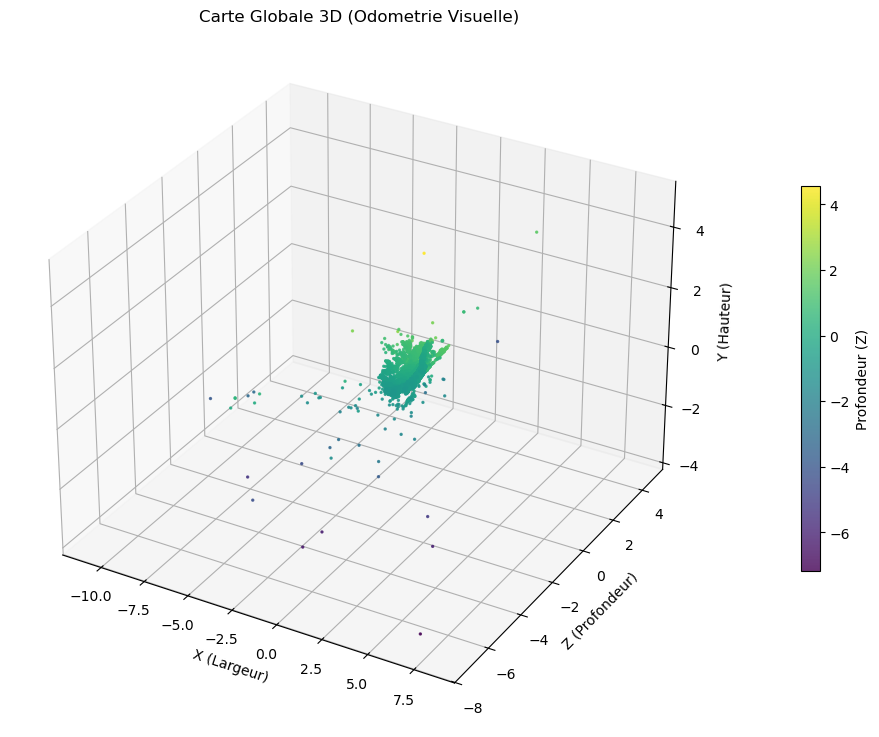

In [4]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# On vérifie qu'on a bien des points
if len(carte_finale_3D) == 0:
    print("La carte est vide, le SLAM a échoué.")
else:
    print(f"Préparation de l'affichage de {len(carte_finale_3D)} points...")

    # Sous-échantillonnage pour éviter que Matplotlib ne plante
    max_points_affichage = 60000
    if len(carte_finale_3D) > max_points_affichage:
        # On choisit 10 000 index au hasard
        indices_aleatoires = np.random.choice(len(carte_finale_3D), max_points_affichage, replace=False)
        p3d_visu = carte_finale_3D[indices_aleatoires]
        print(f"Nuage allégé à {max_points_affichage} points pour Matplotlib.")
    else:
        p3d_visu = carte_finale_3D

    # Création du graphique 3D
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # En OpenCV, Y pointe vers le bas, on l'inverse pour l'affichage (-p3d_visu[:, 1])
    # On utilise 'c=p3d_visu[:, 2]' pour que la couleur change avec la profondeur (Z)
    scatter = ax.scatter(p3d_visu[:, 0], p3d_visu[:, 2], -p3d_visu[:, 1], 
                         s=2, c=p3d_visu[:, 2], cmap='viridis', alpha=0.8)

    ax.set_xlabel('X (Largeur)')
    ax.set_ylabel('Z (Profondeur)')
    ax.set_zlabel('Y (Hauteur)')
    plt.title("Carte Globale 3D (Odometrie Visuelle)")
    
    # Ajout d'une barre de couleur pour comprendre l'échelle de profondeur
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.5, pad=0.1)
    cbar.set_label('Profondeur (Z)')

    plt.show()

Préparation de l'affichage de débogage de 24410 points brut...
Nuage allégé à 10000 points pour Matplotlib.


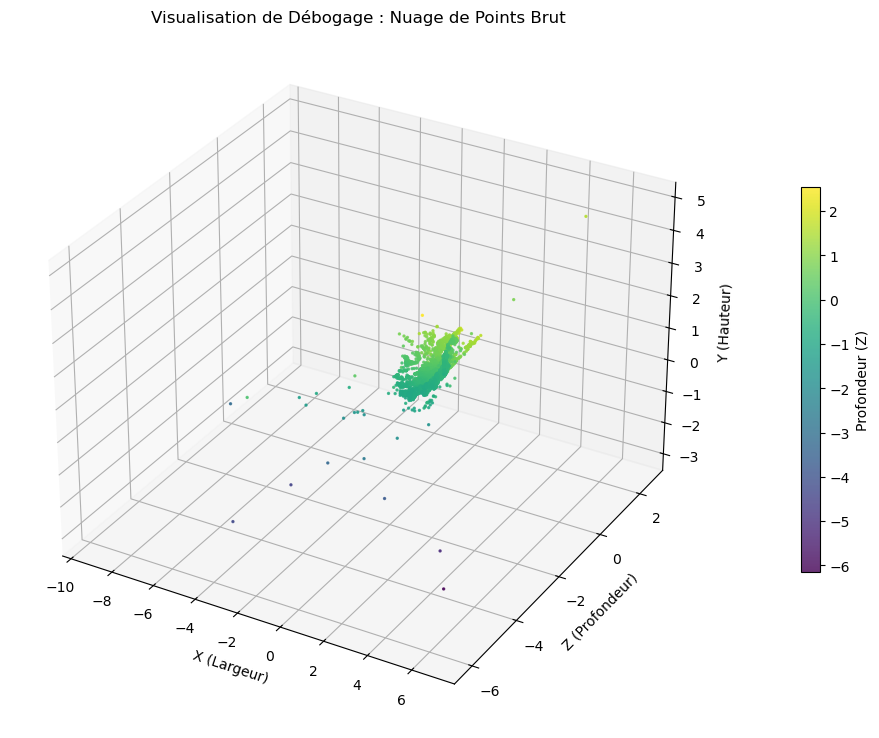

In [5]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# On vérifie qu'on a bien des points
if len(carte_finale_3D) == 0:
    print("La carte est vide, le SLAM a échoué.")
else:
    print(f"Préparation de l'affichage de débogage de {len(carte_finale_3D)} points brut...")

    # Sous-échantillonnage pour éviter que Matplotlib ne plante
    max_points_affichage = 10000
    if len(carte_finale_3D) > max_points_affichage:
        # On choisit 10 000 index au hasard
        indices_aleatoires = np.random.choice(len(carte_finale_3D), max_points_affichage, replace=False)
        p3d_visu = carte_finale_3D[indices_aleatoires]
        print(f"Nuage allégé à {max_points_affichage} points pour Matplotlib.")
    else:
        p3d_visu = carte_finale_3D

    # Création du graphique 3D
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # En OpenCV, Y pointe vers le bas, on l'inverse pour l'affichage (-p3d_visu[:, 1])
    # On utilise 'c=p3d_visu[:, 2]' pour que la couleur change avec la profondeur (Z)
    scatter = ax.scatter(p3d_visu[:, 0], p3d_visu[:, 2], -p3d_visu[:, 1], 
                         s=2, c=p3d_visu[:, 2], cmap='viridis', alpha=0.8)

    ax.set_xlabel('X (Largeur)')
    ax.set_ylabel('Z (Profondeur)')
    ax.set_zlabel('Y (Hauteur)')
    plt.title("Visualisation de Débogage : Nuage de Points Brut")
    
    # Ajout d'une barre de couleur pour comprendre l'échelle de profondeur
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.5, pad=0.1)
    cbar.set_label('Profondeur (Z)')

    plt.show()

(1920, 1080)
Temps : 0.0165 secondes
Matchs trouvés : 689
Points restants après filtrage strict : 324


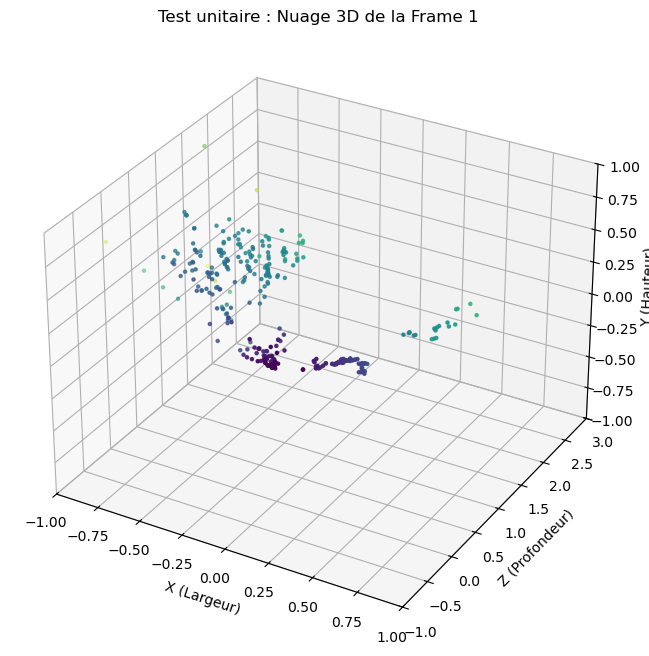

In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from orb_test import generate_cloud

# 1. On génère le nuage d'UNE SEULE frame (la première)
p3d, p2d, desc = generate_cloud(
    PATH_IMG_L='../images_test/set_3_caillou/frame_0001_l.jpg', 
    PATH_IMG_R='../images_test/set_3_caillou/frame_0001_r.jpg'
)

# 2. On applique un filtre STRICT pour enlever les points absurdes
mask = (p3d[:, 2] > 0.2) & (p3d[:, 2] < 3.0) # On garde que ce qui est entre 20cm et 3m devant !
p3d_propre = p3d[mask]

print(f"Points restants après filtrage strict : {len(p3d_propre)}")

# 3. On affiche !
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# On met des limites fixes aux axes pour éviter que 2 points n'écrasent l'échelle
ax.set_xlim([-1, 1]) # 1 mètre à gauche, 1 mètre à droite
ax.set_ylim([-1, 3]) # Profondeur de -1 à 3m (Matplotlib Z)
ax.set_zlim([-1, 1]) # Hauteur (Matplotlib Y inversé)

ax.scatter(p3d_propre[:, 0], p3d_propre[:, 2], -p3d_propre[:, 1], s=5, c=p3d_propre[:, 2], cmap='viridis')

ax.set_xlabel('X (Largeur)')
ax.set_ylabel('Z (Profondeur)')
ax.set_zlabel('Y (Hauteur)')
plt.title("Test unitaire : Nuage 3D de la Frame 1")
plt.show()

(1920, 1080)
Temps : 0.0183 secondes
Matchs trouvés : 689


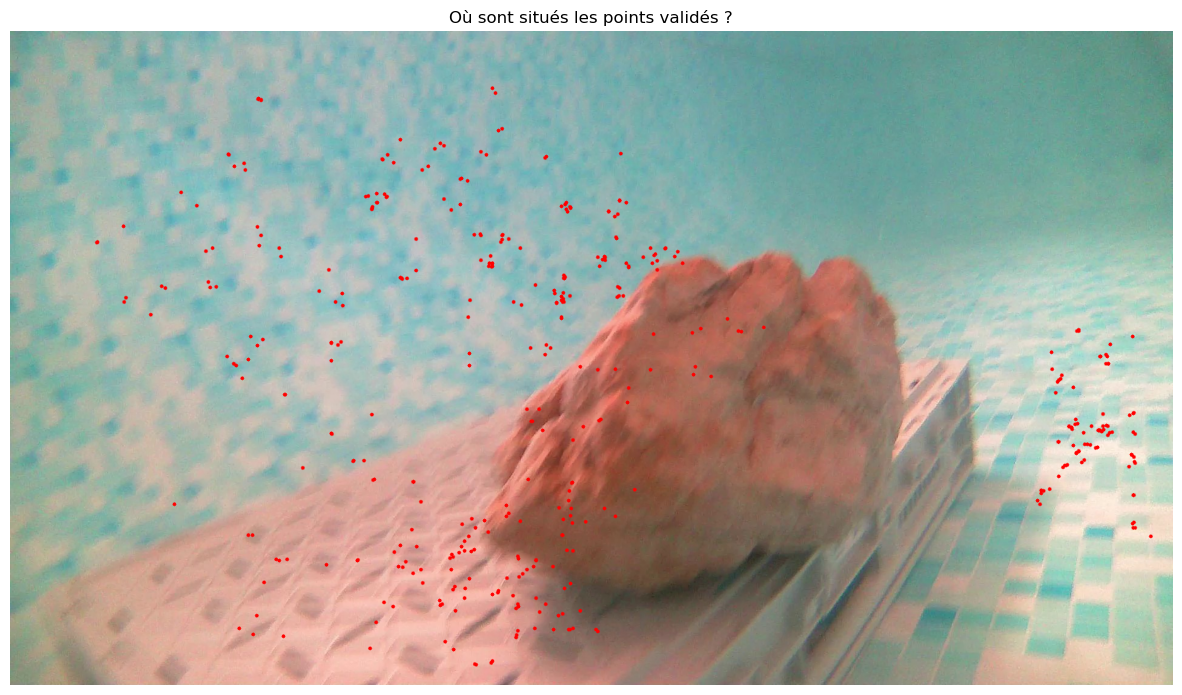

In [9]:
import cv2 as cv
import matplotlib.pyplot as plt
from orb_test import generate_cloud

# On va modifier très légèrement la façon dont on appelle pour récupérer les points bruts
img_l_brute = cv.imread('../images_test/set_3_caillou/frame_0001_l.jpg')
img_r_brute = cv.imread('../images_test/set_3_caillou/frame_0001_r.jpg')

# On récupère les points 2D depuis ta fonction
_, pts2d_gauche, _ = generate_cloud(
    PATH_IMG_L='../images_test/set_3_caillou/frame_0001_l.jpg', 
    PATH_IMG_R='../images_test/set_3_caillou/frame_0001_r.jpg'
)

# Comme ta fonction ne renvoie pas les points droits, on fait un petit hack visuel
# On va afficher l'image gauche avec les points validés par RANSAC
plt.figure(figsize=(15, 10))

# On dessine des petits cercles rouges sur les points validés
img_l_visu = cv.cvtColor(img_l_brute, cv.COLOR_BGR2RGB)
for pt in pts2d_gauche:
    cv.circle(img_l_visu, (int(pt[0]), int(pt[1])), 3, (255, 0, 0), -1)

plt.imshow(img_l_visu)
plt.title("Où sont situés les points validés ?")
plt.axis('off')
plt.show()

In [ ]:
 v

NameError: name 'v' is not defined

: 